# Clustering Analysis
## Understanding and Implementing K-Means, Hierarchical, and DBSCAN Algorithms

# Objective
The objective of this assignment is to understand and implement different clustering algorithms such as K-Means, Hierarchical Clustering, and DBSCAN. This assignment also focuses on preprocessing the dataset, visualizing hidden patterns, evaluating clustering performance, and interpreting the generated clusters.

# Importing Required Libraries
In this step, the required Python libraries for data preprocessing, visualization, clustering, and evaluation are imported.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Loading the Dataset
The dataset is loaded into the notebook using Pandas for further preprocessing and analysis.

In [26]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix,silhouette_score
from sklearn.cluster import KMeans,DBSCAN,AgglomerativeClustering
import scipy.cluster.hierarchy as sch

df=pd.read_excel(r'EastWestAirlines.xlsx')
xls=pd.ExcelFile(r'EastWestAirlines.xlsx')
for sheet in xls.sheet_names:
    df=pd.read_excel(r'EastWestAirlines.xlsx',sheet_name=sheet)
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


# Understanding the Dataset
Basic information about the dataset is analyzed using functions such as head(), shape, info(), and describe() to understand the structure and statistical summary of the data.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [5]:
df.shape

(3999, 12)

In [6]:
df.columns

Index(['ID#', 'Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles',
       'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12',
       'Days_since_enroll', 'Award?'],
      dtype='object')

In [7]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


# Exploratory Data Analysis (EDA)
EDA is performed to understand hidden patterns, relationships, and distributions within the dataset using different visualization techniques.

# Histogram Visualization
Histograms are plotted to analyze the distribution and spread of numerical features in the dataset.

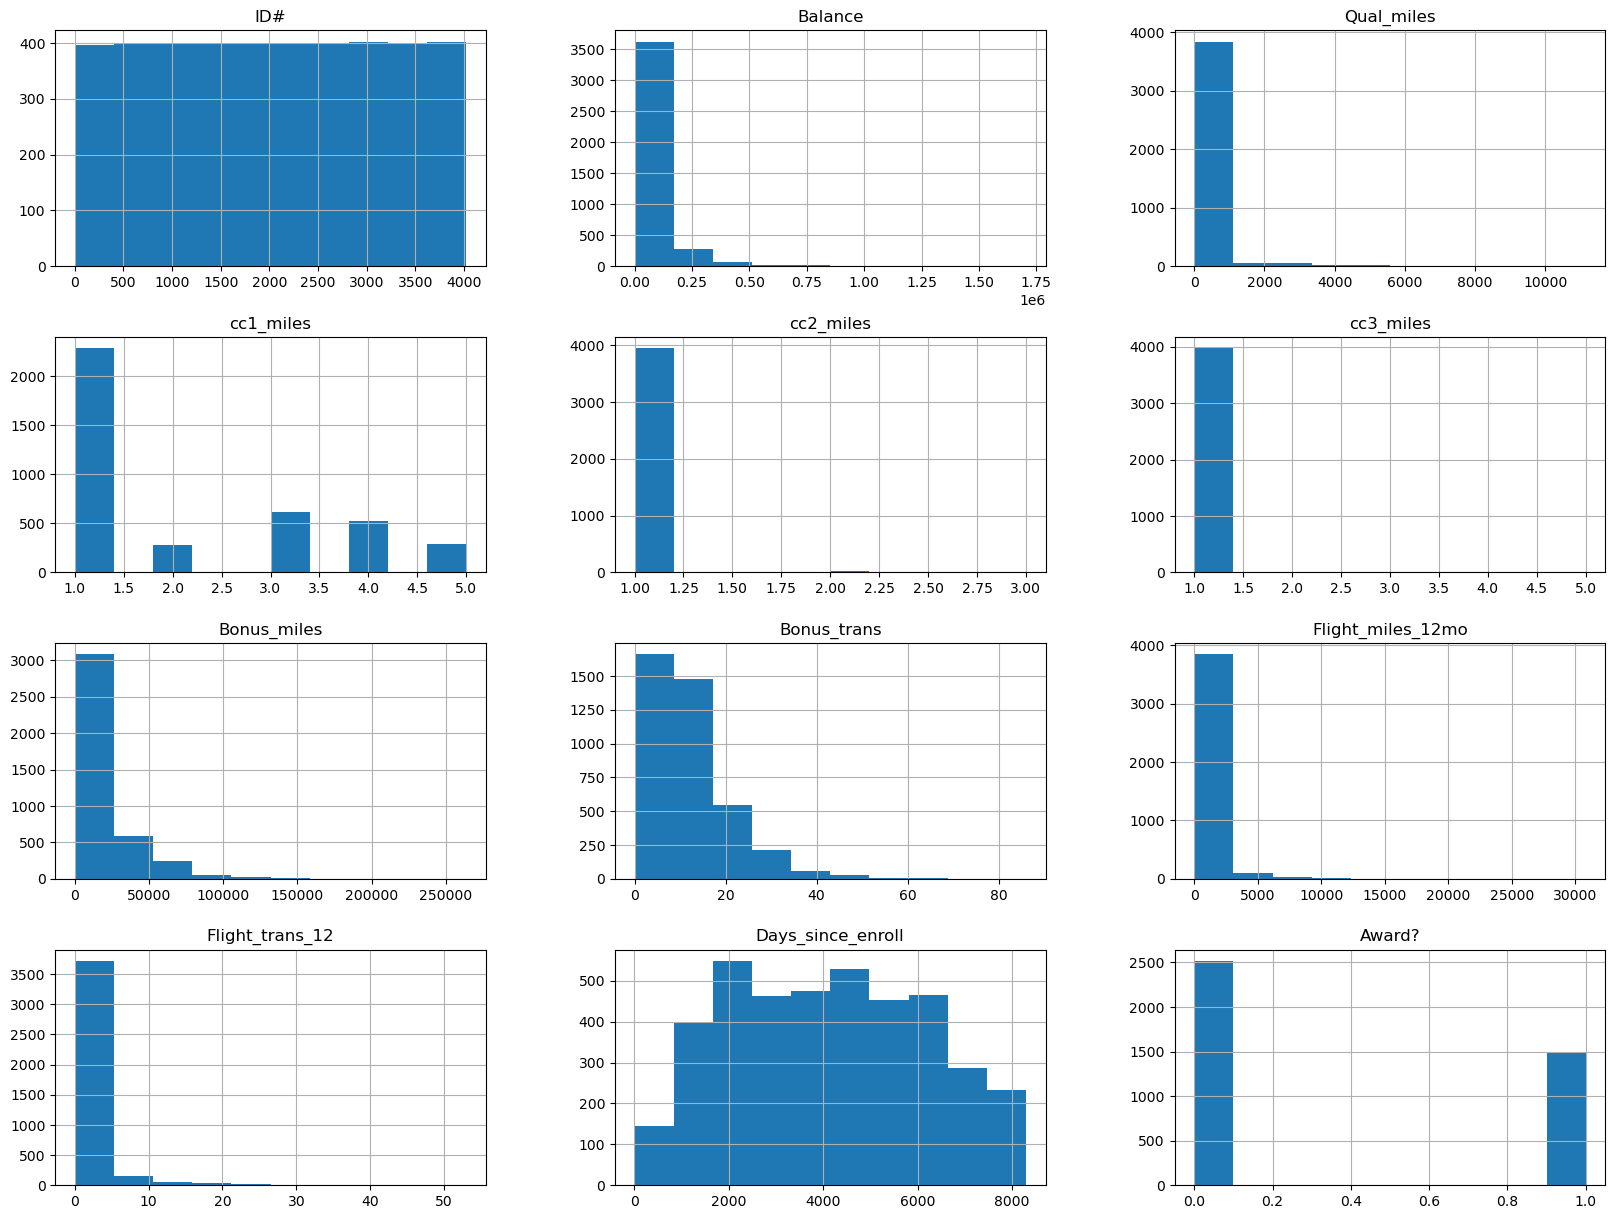

In [8]:
df.hist(figsize=(20,15))
plt.show()

# Checking Missing Values
Missing values are checked to ensure the dataset is clean and suitable for clustering analysis.

In [9]:
df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

# Checking Duplicate Values
Duplicate records are identified and removed to improve clustering quality and maintain data consistency.

In [30]:
df.duplicated().sum()

np.int64(0)

# Outlier Detection
Boxplots are used to identify outliers present in the dataset. Outliers can negatively affect clustering algorithms, especially distance-based clustering methods.

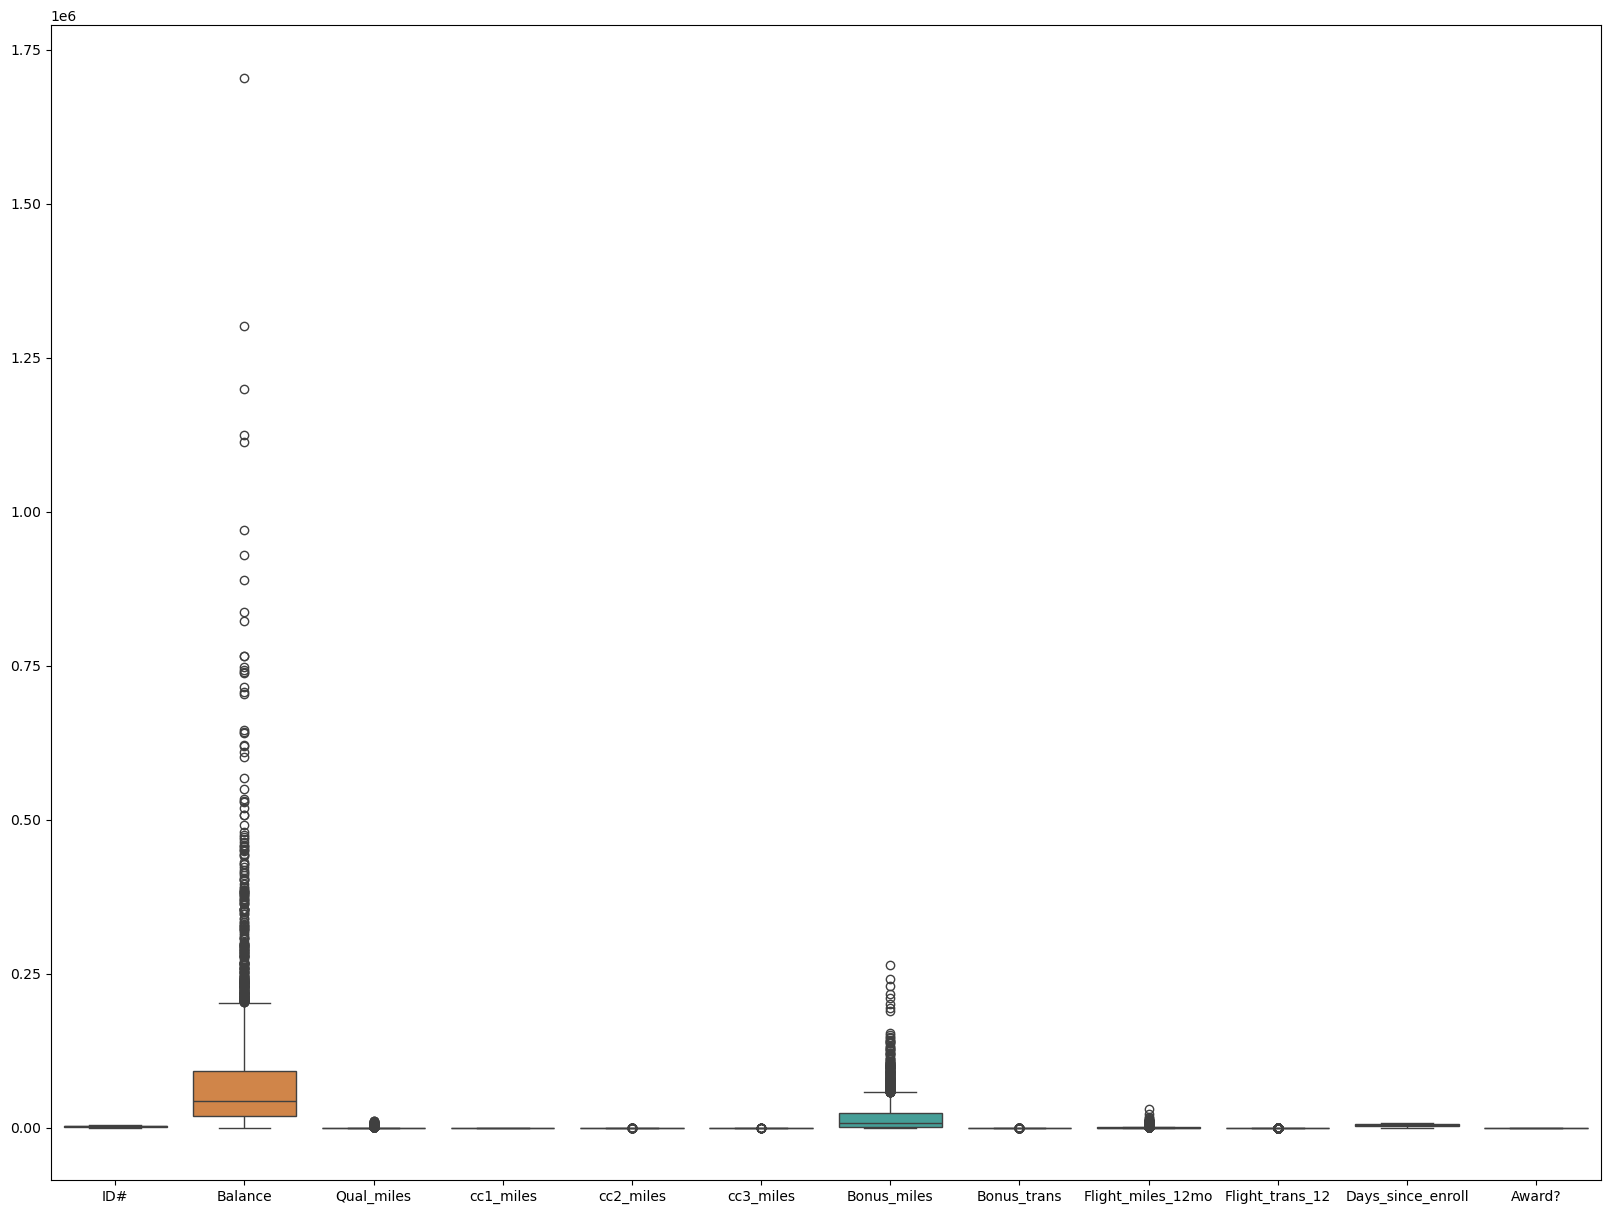

In [11]:
plt.figure(figsize=(20,15))
sns.boxplot(data=df)
plt.show()

In [12]:
df.skew()

ID#                  -0.003343
Balance               5.004187
Qual_miles            7.512395
cc1_miles             0.857569
cc2_miles            11.210459
cc3_miles            17.195532
Bonus_miles           2.842093
Bonus_trans           1.157362
Flight_miles_12mo     7.451666
Flight_trans_12       5.490461
Days_since_enroll     0.120174
Award?                0.537200
dtype: float64

# Correlation Heatmap
A heatmap is generated to visualize the correlation between features and identify feature dependencies.

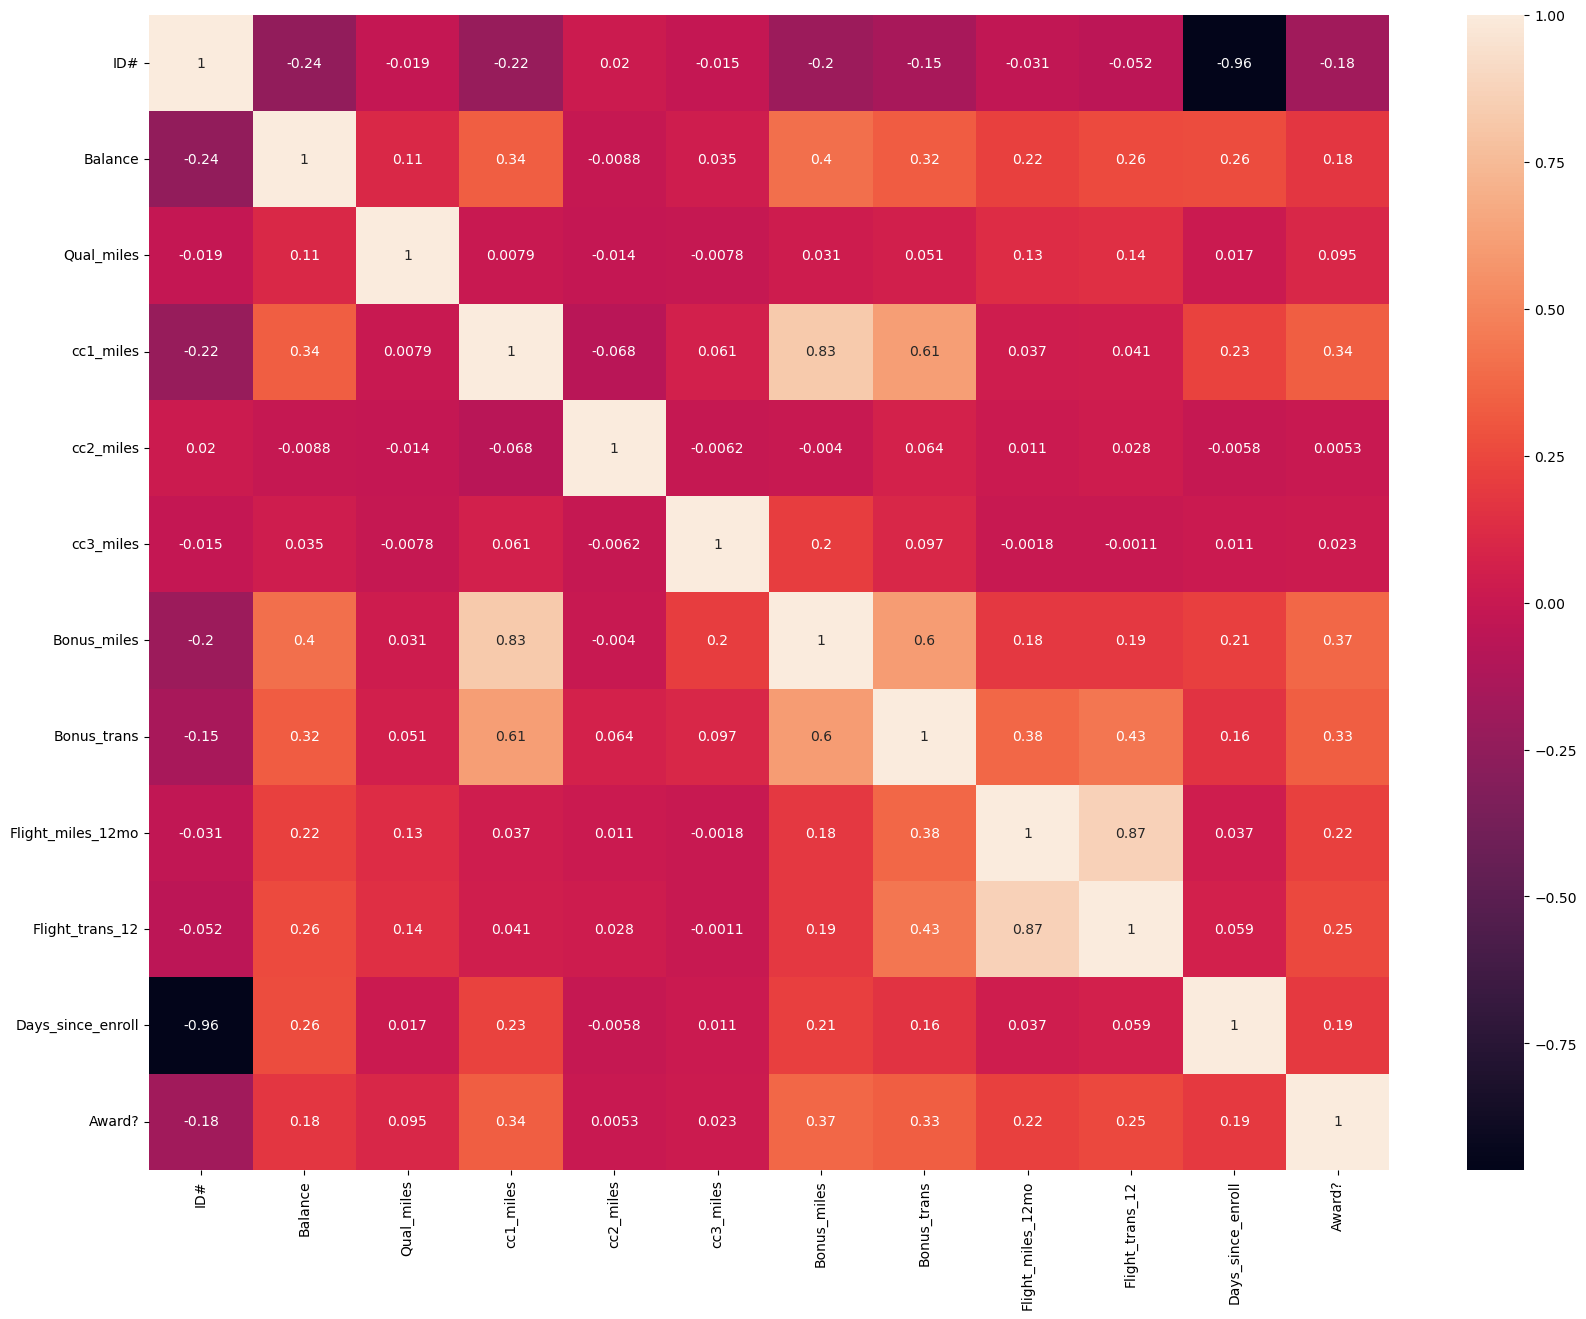

In [13]:
plt.figure(figsize=(20,15))
sns.heatmap(df.corr(),annot=True)
plt.show()

# Feature Scaling
Feature scaling is performed using StandardScaler to normalize the dataset so that all features contribute equally during clustering.

In [14]:
x=df.drop('Award?',axis=1)
y=df['Award?']
ss=StandardScaler()
scaled_x=ss.fit_transform(x)
scaled_x

array([[-1.73512503e+00, -4.51140783e-01, -1.86298687e-01, ...,
        -3.28603258e-01, -3.62167870e-01,  1.39545434e+00],
       [-1.73426342e+00, -5.39456874e-01, -1.86298687e-01, ...,
        -3.28603258e-01, -3.62167870e-01,  1.37995704e+00],
       [-1.73340181e+00, -3.20031232e-01, -1.86298687e-01, ...,
        -3.28603258e-01, -3.62167870e-01,  1.41192021e+00],
       ...,
       [ 1.72682006e+00, -4.29480975e-05, -1.86298687e-01, ...,
        -3.28603258e-01, -3.62167870e-01, -1.31560393e+00],
       [ 1.72768167e+00, -1.85606976e-01, -1.86298687e-01, ...,
         2.85309024e-02, -9.85033311e-02, -1.31608822e+00],
       [ 1.72854328e+00, -7.00507951e-01, -1.86298687e-01, ...,
        -3.28603258e-01, -3.62167870e-01, -1.31754109e+00]],
      shape=(3999, 11))

# K-Means Clustering
K-Means clustering is implemented to partition the dataset into clusters based on similarity between data points.

In [15]:
kmeans = KMeans(n_clusters=3, random_state=42)

kmeans_labels = kmeans.fit_predict(scaled_x)

# Elbow Method
The Elbow Method is used to determine the optimal number of clusters by plotting WCSS values for different K values.

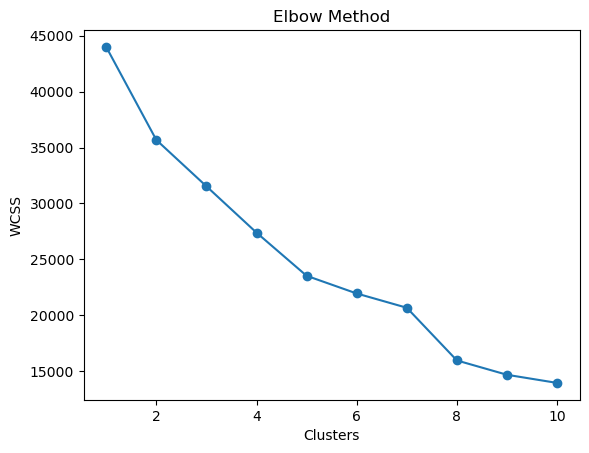

In [16]:
wcss=[]

for i in range(1,11):
    kmeans=KMeans(n_clusters=i,random_state=42)
    kmeans.fit(scaled_x)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

# Dendrogram Visualization
A dendrogram is plotted to visualize the hierarchical relationship between clusters and determine the optimal number of clusters.

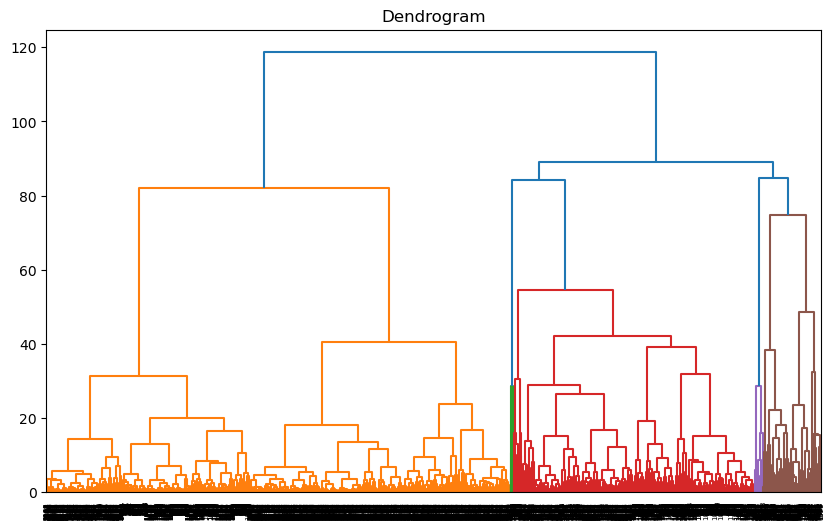

In [17]:
plt.figure(figsize=(10,6))

sch.dendrogram(sch.linkage(scaled_x,method='ward'))

plt.title("Dendrogram")
plt.show()

# Applying Hierarchical Clustering
Agglomerative Hierarchical Clustering is applied to the scaled dataset to generate clusters.

In [22]:
hc=AgglomerativeClustering(n_clusters=3)

hc_labels=hc.fit_predict(scaled_x)

# DBSCAN Clustering
DBSCAN is a density-based clustering algorithm that groups closely packed data points together and identifies noise points.

In [19]:
dbscan=DBSCAN(eps=0.5,min_samples=5)

dbscan_labels=dbscan.fit_predict(scaled_x)

# K-Means Cluster Visualization
Scatter plots are used to visualize the clusters generated by the K-Means algorithm using different colors.

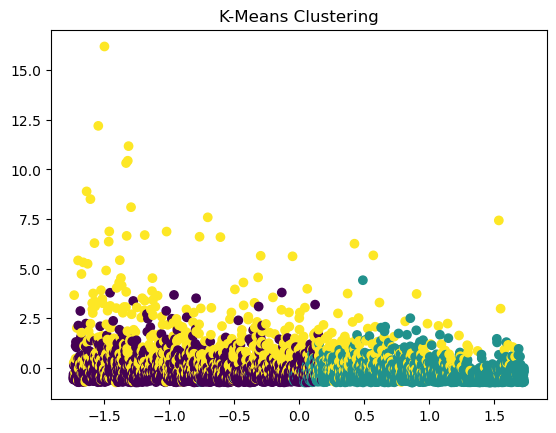

In [20]:
plt.scatter(scaled_x[:,0],scaled_x[:,1],
            c=kmeans_labels,cmap='viridis')

plt.title("K-Means Clustering")
plt.show()

# Hierarchical Cluster Visualization
Scatter plots are used to visualize the clusters generated by Hierarchical Clustering.

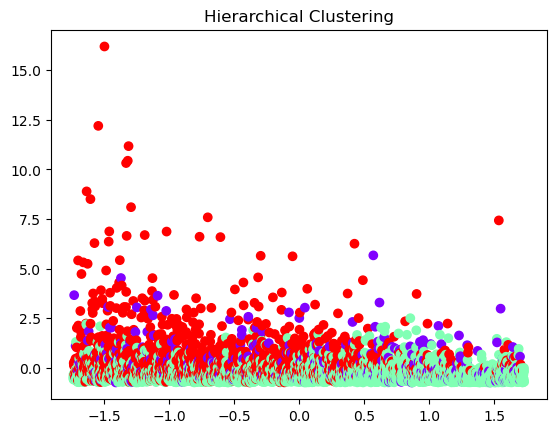

In [23]:
plt.scatter(scaled_x[:,0],scaled_x[:,1],
            c=hc_labels,cmap='rainbow')

plt.title("Hierarchical Clustering")
plt.show()

# DBSCAN Clustering
DBSCAN is a density-based clustering algorithm that groups closely packed data points together and identifies noise points.

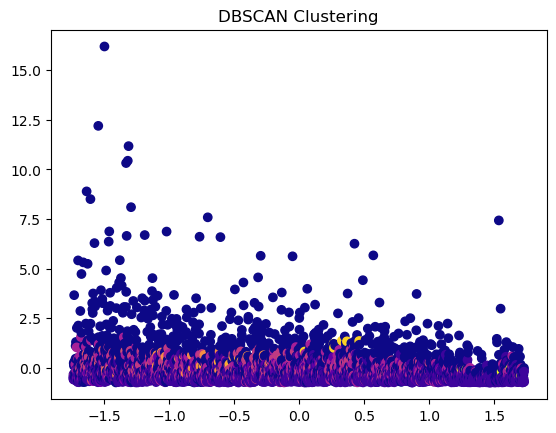

In [24]:
plt.scatter(scaled_x[:,0],scaled_x[:,1],
            c=dbscan_labels,cmap='plasma')

plt.title("DBSCAN Clustering")
plt.show()

# Evaluation using Silhouette Score
Silhouette Score is used to evaluate the quality and separation of clusters generated by clustering algorithms.

In [27]:
kmeans_score=silhouette_score(scaled_x,kmeans_labels)

print(kmeans_score)

0.2366409329087475


In [28]:
dbscan_score=silhouette_score(scaled_x,dbscan_labels)

print(dbscan_score)

-0.2722769217551706


# K-Means Insights
- K-Means formed compact and well-separated clusters.
- The Elbow Method helped in selecting the optimal number of clusters.
- The algorithm performed efficiently on scaled data.

# Hierarchical Clustering Insights
- Hierarchical Clustering provided a clear visualization of cluster hierarchy.
- The dendrogram helped in understanding cluster relationships.
- Ward linkage produced better cluster separation.

# DBSCAN Insights
- DBSCAN effectively detected noise and outlier points.
- It worked well for irregular-shaped clusters.
- The algorithm does not require specifying the number of clusters beforehand.

# Comparison of Clustering Algorithms
| Algorithm | Advantages | Limitations |
|---|---|---|
| K-Means | Fast and simple | Sensitive to outliers |
| Hierarchical | Easy visualization using dendrogram | Computationally expensive |
| DBSCAN | Detects noise and arbitrary shapes | Sensitive to epsilon parameter |

# Conclusion
In this assignment, K-Means, Hierarchical Clustering, and DBSCAN algorithms were successfully implemented and analyzed. Data preprocessing and visualization techniques helped in understanding hidden patterns within the dataset. K-Means produced compact clusters, Hierarchical Clustering provided cluster hierarchy visualization, and DBSCAN effectively handled noise and outliers.